# Projet Data & IA - Prevision de la demande de velos en libre service

**Sujet choisi :** Demande de velos en libre service  
**Dataset :** `14-Hackathon` (courses usagers + historique stations)

Ce notebook suit les etapes obligatoires du projet: definition du probleme, preparation des donnees, EDA, modelisation (2 modeles), interpretation et conclusion.

## 1) Definition du probleme

- **Contexte:** anticiper la demande pour mieux equilibrer les stations de velos.
- **Objectif:** predire le nombre de courses par heure.
- **Variable cible:** `demand` = nombre de trajets agreges par heure.
- **Hypotheses:** la demande depend de l'heure, du jour de semaine, du week-end et de la saison.

In [2]:
# Si besoin dans Jupyter, decommenter:
 #%pip install -q pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

## 2) Collecte et comprehension des donnees

In [4]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path('.')

TRIPS_FEB = BASE_DIR / '14-Hackathon' / '01_Courses_usagers' / '2023_02' / 'All_data_courses.csv'
TRIPS_JUN = BASE_DIR / '14-Hackathon' / '01_Courses_usagers' / '2023_06' / 'All_data_courses_usagers_06_2023.csv'
STATIONS_FILL = BASE_DIR / '14-Hackathon' / '02_Historique_remplissage_stations' / '2023_02' / 'All_data_remplissage.csv'

def read_csv_auto(path):
    if not path.exists():
        print(f"MISSING: {path}")
        return pd.DataFrame()
    
    try:
        df = pd.read_csv(path, sep=';', low_memory=False, encoding='utf-8')
        if df.shape[1] == 1:
            df = pd.read_csv(path, sep=',', low_memory=False, encoding='utf-8')
        return df
    except Exception:
        return pd.DataFrame()

trips_feb = read_csv_auto(TRIPS_FEB)
trips_jun = read_csv_auto(TRIPS_JUN)
stations_fill = read_csv_auto(STATIONS_FILL)

print('Trips fevrier  :', trips_feb.shape)
print('Trips juin     :', trips_jun.shape)
print('Stations fill  :', stations_fill.shape)

if not trips_feb.empty:
    print('Colonnes trips :', list(trips_feb.columns))

Trips fevrier  : (3049914, 16)
Trips juin     : (4543735, 16)
Stations fill  : (5728707, 15)
Colonnes trips : ['id_velo', 'is_VAE', 'Id_user', 'date_depart', 'date_arrive', 'distance', 'duration', 'max_speed', 'from_stat', 'Latitude_start', 'longitude_start', 'start_station_status', 'to_stat', 'latitude_end', 'longitude_end', 'end_station_status']


## 3) Nettoyage et pretraitement

In [5]:
# Harmonisation des colonnes et concat des courses
cols = ['id_velo','is_VAE','Id_user','date_depart','date_arrive','distance','duration','max_speed',
        'from_stat','Latitude_start','longitude_start','start_station_status',
        'to_stat','latitude_end','longitude_end','end_station_status']

trips = pd.concat([trips_feb[cols], trips_jun[cols]], ignore_index=True)

trips['date_depart'] = pd.to_datetime(trips['date_depart'], errors='coerce')
trips['date_arrive'] = pd.to_datetime(trips['date_arrive'], errors='coerce')
for c in ['distance','duration','max_speed','Latitude_start','longitude_start','latitude_end','longitude_end']:
    trips[c] = pd.to_numeric(trips[c], errors='coerce')

trips['is_VAE'] = trips['is_VAE'].astype(str).str.lower().map({'true':1, 'false':0})

initial_n = len(trips)
trips_clean = trips.dropna(subset=['date_depart', 'distance', 'duration']).drop_duplicates().copy()
trips_clean = trips_clean[(trips_clean['duration'] > 0) & (trips_clean['distance'] >= 0)]
trips_clean = trips_clean[trips_clean['max_speed'].fillna(0).between(0, 80)]

print(f'Lignes initiales  : {initial_n:,}')
print(f'Lignes conservees : {len(trips_clean):,}')
print(f'Taux conserve     : {len(trips_clean)/initial_n:.2%}')

Lignes initiales  : 7,593,649
Lignes conservees : 7,593,649
Taux conserve     : 100.00%


In [ ]:
# Creation de la cible horaire (demande)
trips_clean['hour'] = trips_clean['date_depart'].dt.floor('h')
demand_hourly = trips_clean.groupby('hour').size().reset_index(name='demand').sort_values('hour')

# Features temporelles
for col_name, accessor in [('month','month'), ('day','day'), ('dayofweek','dayofweek'), ('hour_of_day','hour')]:
    demand_hourly[col_name] = getattr(demand_hourly['hour'].dt, accessor)

demand_hourly['is_weekend'] = (demand_hourly['dayofweek'] >= 5).astype(int)
demand_hourly['sin_hour'] = np.sin(2*np.pi*demand_hourly['hour_of_day']/24)
demand_hourly['cos_hour'] = np.cos(2*np.pi*demand_hourly['hour_of_day']/24)
demand_hourly['sin_dow'] = np.sin(2*np.pi*demand_hourly['dayofweek']/7)
demand_hourly['cos_dow'] = np.cos(2*np.pi*demand_hourly['dayofweek']/7)

# Lags
demand_hourly['lag_1'] = demand_hourly['demand'].shift(1)
demand_hourly['lag_24'] = demand_hourly['demand'].shift(24)
demand_hourly = demand_hourly.dropna().reset_index(drop=True)

demand_hourly.head()

,hour,demand,month,day,dayofweek,hour_of_day,is_weekend,sin_hour,cos_hour,sin_dow,cos_dow,lag_1,lag_24
0,2023-01-23 10:00:00,1,1,23,0,10,0,0.500000,-8.660254e-01,0.000000,1.000000,1.0,1.0
1,2023-01-24 14:00:00,1,1,24,1,14,0,-0.500000,-8.660254e-01,0.781831,0.623490,1.0,1.0
2,2023-01-25 14:00:00,1,1,25,2,14,0,-0.500000,-8.660254e-01,0.974928,-0.222521,1.0,1.0
3,2023-01-25 18:00:00,1,1,25,2,18,0,-1.000000,-1.836970e-16,0.974928,-0.222521,1.0,1.0
4,2023-01-25 19:00:00,1,1,25,2,19,0,-0.965926,2.588190e-01,0.974928,-0.222521,1.0,1.0


## 4) EDA - Analyse exploratoire

Periode: 2023-01-23 10:00:00 -> 2023-06-30 23:00:00
Points horaires: 1503
Demande moyenne: 5052.31


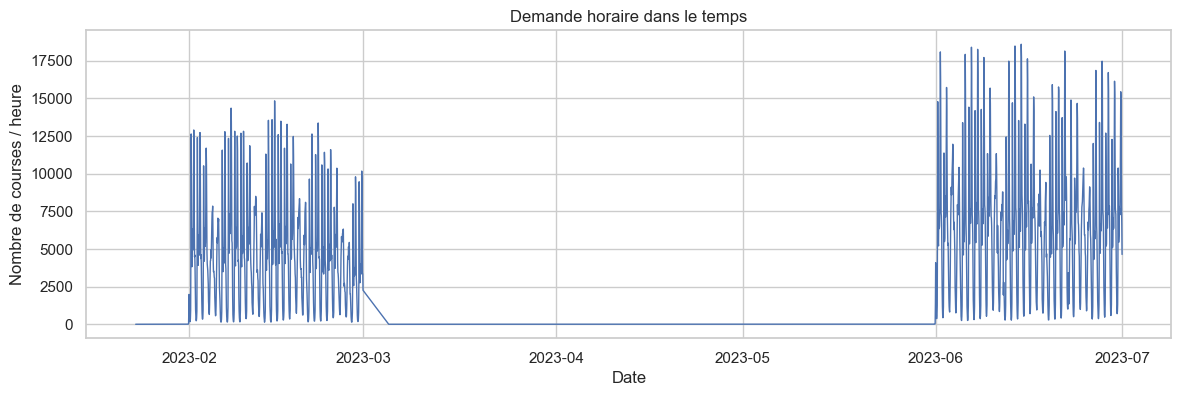

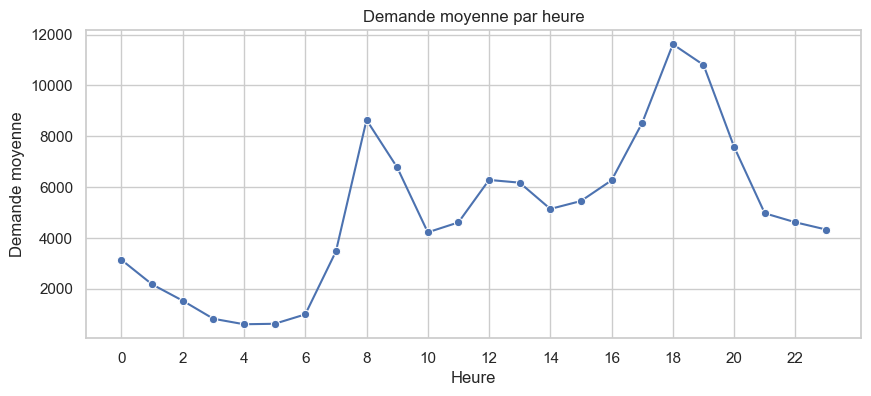

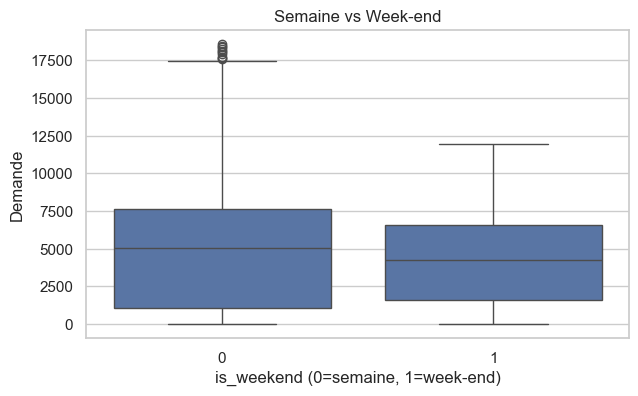

In [7]:
print('Periode:', demand_hourly['hour'].min(), '->', demand_hourly['hour'].max())
print('Points horaires:', len(demand_hourly))
print('Demande moyenne:', round(demand_hourly['demand'].mean(), 2))

plt.figure(figsize=(14, 4))
plt.plot(demand_hourly['hour'], demand_hourly['demand'], linewidth=1)
plt.title('Demande horaire dans le temps')
plt.xlabel('Date')
plt.ylabel('Nombre de courses / heure')
plt.show()

hour_profile = demand_hourly.groupby('hour_of_day', as_index=False)['demand'].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(data=hour_profile, x='hour_of_day', y='demand', marker='o')
plt.title('Demande moyenne par heure')
plt.xlabel('Heure')
plt.ylabel('Demande moyenne')
plt.xticks(range(0,24,2))
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=demand_hourly, x='is_weekend', y='demand')
plt.title('Semaine vs Week-end')
plt.xlabel('is_weekend (0=semaine, 1=week-end)')
plt.ylabel('Demande')
plt.show()

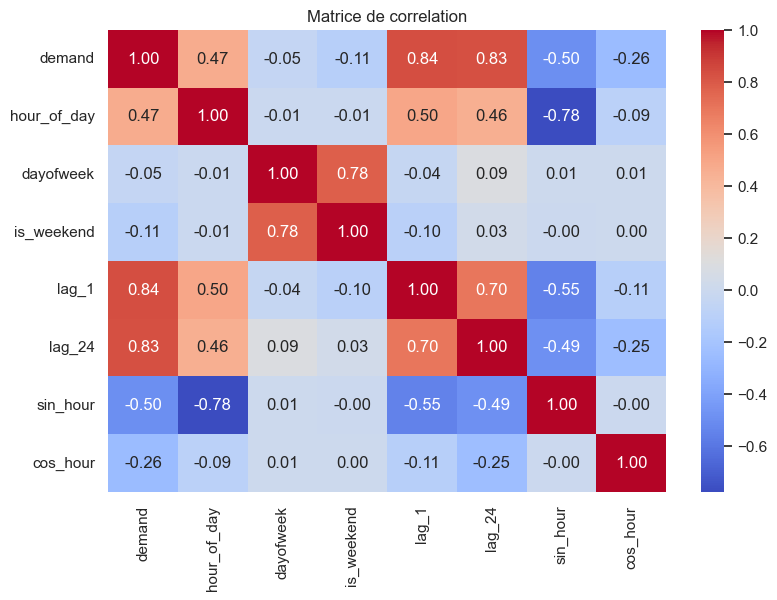

In [8]:
corr_cols = ['demand','hour_of_day','dayofweek','is_weekend','lag_1','lag_24','sin_hour','cos_hour']
plt.figure(figsize=(9,6))
sns.heatmap(demand_hourly[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation')
plt.show()

## 5) Modelisation - 2 modeles

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

feature_cols = ['month','day','dayofweek','hour_of_day','is_weekend','sin_hour','cos_hour','sin_dow','cos_dow','lag_1','lag_24']
X = demand_hourly[feature_cols]
y = demand_hourly['demand']

split_idx = int(len(demand_hourly) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

models = {
    'RandomForest': RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results = []
preds_test = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    preds_test[name] = pred

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    tscv = TimeSeriesSplit(n_splits=4)
    cv_scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_mae = -cv_scores.mean()

    results.append({
        'Model': name, 
        'MAE_test': mae, 
        'RMSE_test': rmse, 
        'R2_test': r2, 
        'CV_MAE_train': cv_mae
    })

results_df = pd.DataFrame(results).sort_values('RMSE_test')
print(results_df)

              Model    MAE_test    RMSE_test   R2_test  CV_MAE_train
1  GradientBoosting  647.703094   969.797246  0.944417    657.044813
0      RandomForest  684.280399  1119.424341  0.925942    622.076013


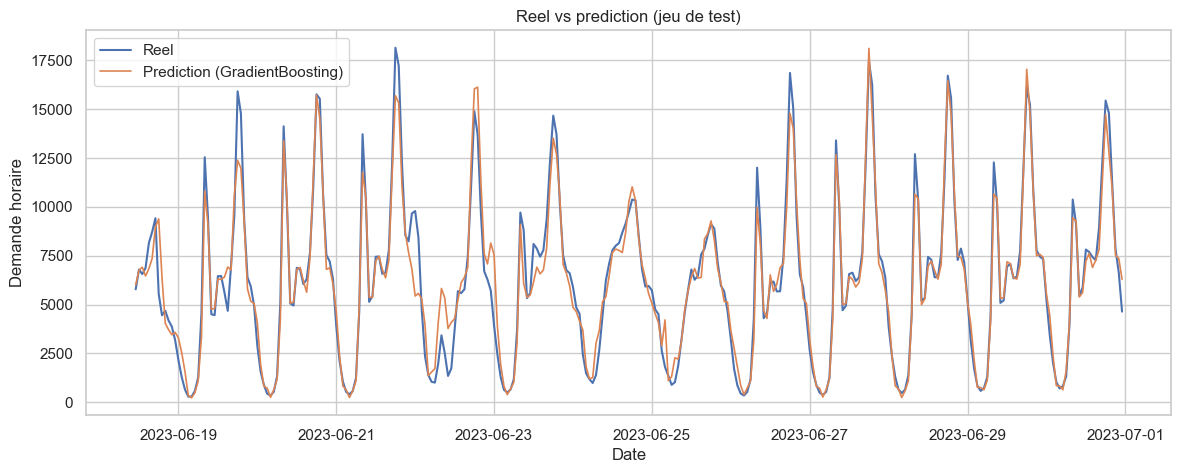

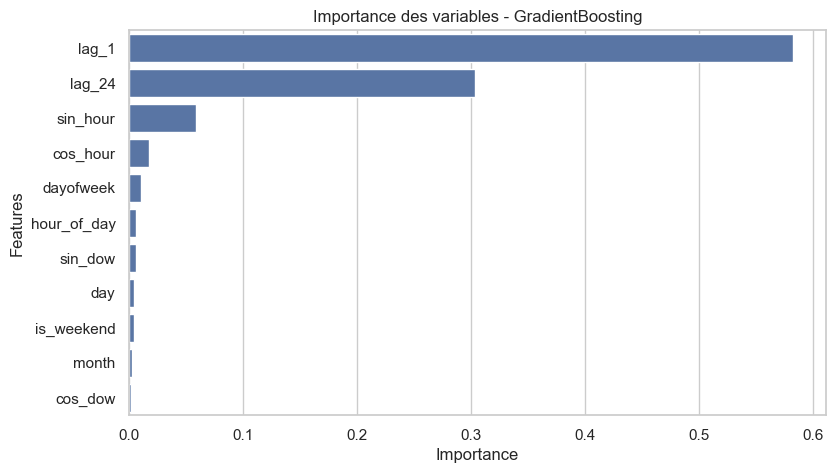

lag_1          0.582276
lag_24         0.303455
sin_hour       0.059099
cos_hour       0.017391
dayofweek      0.011041
hour_of_day    0.006464
sin_dow        0.006432
day            0.004716
is_weekend     0.004285
month          0.002907
dtype: float64

In [11]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = preds_test[best_model_name]

plot_df = demand_hourly.iloc[split_idx:].copy()
plot_df['y_true'] = y_test.values
plot_df['y_pred'] = y_pred_best

plt.figure(figsize=(14,5))
plt.plot(plot_df['hour'], plot_df['y_true'], label='Reel', linewidth=1.5)
plt.plot(plot_df['hour'], plot_df['y_pred'], label=f'Prediction ({best_model_name})', linewidth=1.2)
plt.title('Reel vs prediction (jeu de test)')
plt.xlabel('Date')
plt.ylabel('Demande horaire')
plt.legend()
plt.show()

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(9,5))
    sns.barplot(x=imp.values, y=imp.index, orient='h')
    plt.title(f'Importance des variables - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()
    display(imp.head(10))

## 6) Interpretation et explicabilite

- Les variables temporelles (heure, jour, week-end) influencent fortement la demande.
- Les lags `lag_1` et `lag_24` capturent l'inertie de la serie temporelle.
- Le meilleur modele est selectionne selon `RMSE`, `MAE`, `R2` et une validation croisee temporelle.

**Limites:** seulement deux mois de donnees (fevrier + juin), pas de meteo, pas d'evenements exogenes.

**Pistes d'amelioration:** ajout meteo/jours feries, modelisation par station, modeles temporels avances (XGBoost, Prophet, etc.).

## 7) Conclusion

Ce projet propose une base solide pour predire la demande horaire de velos en libre service avec des modeles de regression.

Le notebook est reproductible, contient les visualisations demandees, et peut etre etendu pour un niveau plus avance (variables exogenes, prediction par station, optimisation reequilibrage).